In [2]:
####################################################################
##  First part: import libraries                                  #
##################################################################

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline  
import os
import rasterio
import rasterio.features
import rasterio.warp
from osgeo import gdal
from matplotlib import pyplot
from rasterio.plot import show 
import geopandas as gpd
from osgeo import ogr, osr
import math

import re

from rasterstats import zonal_stats

In [3]:
# Especifica la dirección (directorio) en la que deseas buscar archivos
direccion = 'D:\giambelluca.144055\Incendios\Proyecto\Mag_L457_Catalunia'

# Obtén la lista de archivos en la dirección especificada de los incendios 
archivos = [archivo for archivo in os.listdir(direccion) if os.path.isfile(os.path.join(direccion, archivo))]

In [4]:
df=gpd.read_file('D:\giambelluca.144055\Incendios\Proyecto\Capas\MFE_1985_unidos\Capa_intermedia\BOSQUES_Catalunia_MFE85_4326.shp')
df['FECHA']=df['FECHA'].astype(int)
df['ID_total']=df['ID_total'].astype(np.float32)


In [6]:
from osgeo import gdal, ogr
import numpy as np

#Imporrtar el ráster con los datos de bosques 
bosques_dir = "D:\giambelluca.144055\Incendios\Proyecto\Rasters_stat\Bosques_MFE85\Bosques_Catalunia_MFE85.tif"

bosques=gdal.Open(bosques_dir)
Bosques=bosques.GetRasterBand(1).ReadAsArray()
#Crear un dataframe que contenga los datos de incendios y bosques

# df=pd.DataFrame()
# df['ID_bosque']=[4235,4235,4220,4235,4235,4235,4235,4220,4220,4220,4235,4235,4235,4220,4220,4220,4220,4235,4120,4120,4120,4135,4120,4120,4120,4120,4120,4120,4120,4120,4120,4120,4120,4120,4120,4120,4120,4120,4120,4120,4135,4120,4120,4120,4120,4120,4120,4235,4120,4120,3120,3117,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3220,3113,3120,3248,3220,3220,3220,3120,3120,3120,3120,3120,3148,3120,3120,3148,3148,3148,3148,3120,3120,3148,3120,3120,3120,3129,3120,3113,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3120,3320,3320,3320,3320,3320,3320,3320,3320,3348,3320,3320,332,3320,3320,3320,3320,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420,3420,3448,3420,3420,3420,3420,3220,3220,3220,3220,3220,3220,3220,3220,3320,3320,3220,3220,3320,3320,3320,3320,3320,3320,3320,3320,3320,3320,3320,3320,3320,3320,3320,3320,3320,3320,3320,3320,3520,3520,3520,3520,3520,3520,3520,3520,3635,3620,3520,3616,3620,3620,3620,3635,3620,3621,3635,3635,3621,3620,3620,3620,3620,3620,3644,3635,3635,3635,3620,3620,3420,3420,3420,3420,3448,3420,3420,3420,3420,3448,3420,3448,3420,3420,3420,3420,3520,3520,3448,3420,3520,3520,3520,3520,3520,3520,3520,3520,3520,3520,3520,3520,3820,3820,3820,3820,3820,3820,3835,3820,3820,3820,3835,3835,3835,3920,3820,3820,3920,3920,3935,3920,4020,4020,3920,3920,4020,4020,4020,4020,4120,4120,4120,4120,3620,3625,3621,3622,3620,3635,3635,3620,3620,3620,3620,3620,3620,3620,3620,3648,3622,3720,3635,3635,3735,3720,3720,3720,3820,3820,3720,3735,3820,3835,3820,3820,2029,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2021,2020,2020,2020,2020,2034,2020,2020,2033,2020,2020,2020,2029,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2021,2020,2020,2020,2021,202,2020,2021,2020,2020,2021,2020,2020,2020,2020,2020,2021,2020,2020,2020,2020,2016,2046,2020,2020,2020,2021,2021,2021,2020,2020,2044,2020,2020,2021,2020,2021,2021,2021,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2033,2020,2020,2020,2020,2020,2020,2035,2035,2020,2035,2020,2046,2035,2021,2020,2044,2020,2020,2020,2020,2021,2016,2021,2044,2046,2020,2021,2013,2021,2013,2044,2021,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2044,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2044,2044,2020,2020,2020,2033,2020,2034,2020,2020,2020,2033,2033,2020,2020,2020,2020,2020,2033,2033,2033,2034,2033,2020,2035,2034,2033,2020,2020,2020,2035,2020,2020,2020,2020,2020,212,2134,2135,2120,2120,2129,2129,2120,2120,2120,2120,2120,2220,2220,2134,2120,2220,2220,2220,2221,2220,2229,2221,2220,2221,2220,2220,2220,2220,2220,2220,2220,212,2120,2013,2128,2120,212,212,212,212,2148,2120,2120,2129,212,2129,2134,2120,2128,212,2120,2135,2134,2135,2120,2120,2120,212,2120,2134,2135,2129,212,2020,202,2021,2020,2020,2034,2020,2020,2033,2020,2020,2020,2020,2020,2033,2020,2021,2021,2034,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2034,2020,2020,2020,2020,2020,2020,2020,2033,2020,2020,2034,2020,2021,2033,2020,2020,2020,2020,2020,2020,2033,2020,2020,2020,2015,2020,2033,2020,2021,2020,2020,2021,202,2015,2020,2020,2020,2020,2020,2020,2020,2033,2020,2020,2020,2020,2021,2020,2020,2020,2020,2020,2033,2020,2033,2020,2020,2033,2033,2033,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2034,2013,2020,2020,2020,2033,2020,2044,2044,2044,2044,2020,2020,2020,2020,2020,2020,2020,2020,2048,2020,2020,2015,2020,2020,2020,2020,2020,2048,2020,2021,2048,2048,2044,2020,2033,2044,2048,2033,2020,2020,2020,2020,2021,2020,2020,2020,2020,2020,2020,2021,2044,2033,2033,2020,2021,2020,2015,2020,2020,2020,2029,2020,2020,2020,2021,2020,2020,2020,2021,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2048,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2033,2020,2020,2020,2020,2020,2020,2020,2020,2020,2021,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2034,2021,2020,2021,2034,2020,2020,2020,2020,2020,2020,2020,2021,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2831,2820,2820,2820,2820,2848,2820,2820,2820,2820,2848,2848,2820,2820,2820,2820,2848,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2823,2813,2820,2820,2820,2835,2820,2820,2820,2820,2848,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2848,2820,2820,2848,2820,2820,2820,2820,2820,2820,2820,2920,2920,2920,2922,2920,2921,2920,2920,2920,3020,2935,2948,3020,3020,3020,3020,3020,3020,3020,3020,3120,3129,3029,3121,3120,3120,3120,3117,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2820,2848,2848,2820,2820,2820,2835,2820,2820,2820,2820,2820,2848,2820,2848,3135,3135,3120,3134,3120,3120,3135,3121,3135,3120,3120,3120,3135,3135,3135,3135,3135,3120,3120,3135,3120,3120,3135,3120,3120,3135,3125,3129,3120,3135,3121,3120,3120,3120,3120,3135,3120,3135,3120,3120,3120,3120,3135,3120,3120,3120,3120,3135,3135,3135,3135,3135,3121,3135,3120,3148,3120,3120,3135,3121,3120,3120,3120,3120,3120,3120,3120,3135,3135,3135,3120,3120,3120,3120,3120,3135,3133,3148,3121,3120,3133,3120,3120,3120,3120,3120,3135,3113,3134,3120,3120,3120,3120,3148,3120,3120,3120,3120,3120,3120,3121,3135,3120,3135,3120,3120,3121,3120,3120,3135,3121,3121,3125,3120,3120,3116,3120,3135,3120,3120,3120,3120,3120,3120,3120,3135,3133,3135,2235,2221,2248,2235,2235,2235,2220,2229,2235,2220,2220,2220,2220,2220,2220,2235,2220,2220,2220,2234,222,2220,2220,2220,2235,2220,2220,2220,2220,2235,222,2215,222,2220,2248,2234,2220,2220,2248,2248,2220,2220,2220,2220,2220,2220,2220,2220,2220,2220,2220,2235,2235,2220,2220,2220,2220,2220,2220,2220,2220,2221,2235,2233,2220,2220,2220,2220,2235,2220,2220,2248,2220,2220,2220,2221,222,2220,2220,2221,2221,2220,222,2220,2220,2221,2220,2235,2235,2220,2220,2220,2235,2220,2220,2220,2220,2235,2220,2220,2220,2220,2220,2220,2220,2220,222,2220,2220,2221,2248,2220,2221,2220,2220,2220,2220,2220,2220,222,2235,222,2220,2248,2220,2229,2220,222,2535,2535,2423,2423,252,2520,2535,2520,252,2623,2535,2535,2635,2620,2635,2635,2635,2623,2635,2620,2720,2720,2720,2720,2720,2820,2720,2720,2820,2820,2820,2820,2229,2220,2220,2220,2220,2220,2220,2235,2220,2220,2229,2220,2235,2220,2220,2220,2320,2335,2220,2335,2420,242,2320,2320,2423,2435,2435,2423,2420,2420,2420,2423,2820,2820,2823,2820,2829,2835,2820,2823,2835,2820,2820,2820,2820,2820,2820,2835,2820,2820,2820,2820,2820,2820,2848,2848,2820,2820,2820,2820,2820,2820,2820,2820,2820,2848,2820,2820,2820,2848,2848,2820,2820,2820,2820,2820,2848,2820,2848,2820,2820,2835,2835,2820,2820,2820,2820,2829,2820,2820,2820,2820,2820,2820,2835,2820,139,139,134,139,139,117,139,117,139,139,123,139,135,139,139,139,135,135,139,135,123,139,129,135,139,139,135,123,135,135,139,135,123,134,123,139,123,123,139,123,139,139,117,139,139,134,139,135,139,139,139,135,139,117,139,139,135,135,117,139,139,139,134,139,135,135,135,139,135,139,139,139,123,139,135,123,11,135,139,139,139,139,123,139,139,139,139,139,123,139,139,139,139,139,139,139,135,139,135,135,139,139,135,135,139,139,139,117,135,139,139,135,135,135,139,135,122,120,123,123,135,139,123,135,139,139,139,139,439,417,423,439,417,439,439,423,423,423,417,423,420,439,423,420,439,439,439,439,439,435,439,435,423,423,420,423,129,139,135,129,220,348,139,119,313,329,348,348,348,348,348,348,417,417,329,348,417,417,417,417,439,439,439,417,439,439,439,417,423,417,439,439,439,439,423,439,422,439,439,439,417,422,423,435,439,423,417,535,635,448,417,634,635,620,627,620,635,620,635,417,417,423,417,423,423,423,417,420,423,439,439,439,417,439,439,439,439,439,439,417,417,439,417,423,417,423,439,139,139,139,139,139,139,139,139,123,139,123,123,139,123,139,139,139,139,123,139,139,117,139,139,139,139,139,139,135,139,139,139,139,139,123,139,139,139,143,139,123,139,116,135,139,139,139,139,116,11,139,116,131,139,148,139,139,120,116,139,129,139,139,123,135,139,139,122,122,135,123,120,139,135,135,148,148,139,139,148,116,148,148,145,139,120,120,135,139,139,139,148,148,135,148,139,139,139,129,139,139,135,139,139,139,139,139,120,123,123,123,113,139,122,123,139,139,139,139,139,139,123,139,135,135,123,123,148,148,148,148,139,148,148,148,148,139,139,148,139,148,139,148,139,139,135,139,139,129,148,139,139,139,139,148,148,148,148,110,148,139,148,148,135,139,148,148,135,139,134,129,139,139,134,135,148,148,148,148,148,139,148,148,148,148,148,148,148,148,148,148,139,139,139,139,116,148,129,129,129,139,148,139,139,122,122,139,123,139,139,139,139,139,139,139,139,139,139,139,139,135,135,135,123,148,139,139,139,139,135,139,139,135,11,139,139,135,135,139,139,135,139,139,139,139,148,139,139,139,148,139,139,135,139,139,1539,1534,1510,1510,1510,1531,1539,1534,1629,1621,1527,1539,1620,1620,1629,1621,1633,1620,1621,1629,1620,1621,1629,1620,1620,1616,1620,1620,1620,1621,1629,1621,1420,1420,1420,1420,1420,1421,1420,1420,1534,1539,1420,1420,1527,1510,1527,151,1510,1524,1536,1539,1510,1511,1539,1539,1524,1510,1510,1539,1527,1539,1531,1510,1820,1820,1820,1820,1820,1820,1820,1820,1820,1820,1816,1820,1820,1820,1820,182,1820,1820,1820,1820,1920,1935,1820,1820,1920,1935,1921,1920,1921,1920,1935,1935,1720,1720,1720,1720,1720,1720,1720,1733,1720,1720,1720,1720,1720,1720,1720,1720,1720,1720,1720,1720,1720,1720,1734,1733,1733,1720,1720,1720,1820,1820,1820,1820,2015,2020,2015,2020,2020,2020,2033,2020,2020,2020,2034,2021,2020,2020,2020,2021,2020,2034,2034,2034,2021,2020,2020,2020,2020,2020,2020,2020,2021,2020,2020,2020,1935,1935,1935,1935,1935,1935,1935,1935,1920,1935,1920,1935,2015,2020,2033,2020,2020,2033,202,2020,2015,2046,2029,2020,2029,2020,2020,2029,2020,2029,2029,2015,2020,2033,2033,2020,2020,2020,2020,2020,2020,2033,2020,2033,2022,2020,2033,2020,2033,2033,2020,2020,2033,2033,2020,2020,2033,2033,2020,2021,2034,2020,2034,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2020,2035,2020,2020,2033,2015,2033,2020,2020,2020,2020,2034,2020,2020,2020,2020,2020,2020,2033,2020,2029,2020,2033,934,934,934,921,934,934,934,934,921,934,921,934,934,934,934,921,1035,1035,934,1020,1035,1034,1035,1035,1034,1035,1020,1035,1034,1035,1015,1035,733,721,733,721,735,733,748,721,721,721,748,721,733,721,733,721,735,735,721,721,816,835,721,820,820,835,835,835,921,934,934,935,1233,1225,1234,1225,1225,1225,1225,1234,1225,1225,1225,1225,1225,1225,1225,1229,1225,1225,1234,1233,1225,1225,1233,1225,1321,1320,1225,1225,1329,1321,1320,1320,1035,1035,1035,1035,1035,1035,1020,1035,1035,1029,1035,1035,1035,1013,1035,1035,1034,1035,1035,1034,1035,1139,1020,1035,1139,1134,1139,1123,1225,1234,1234,1234,1420,1420,1420,1420,1420,1420,1420,1434,1420,1420,1420,1434,1421,1420,1420,1421,1421,1420,1420,1421,1421,1420,1420,1420,1420,1421,1421,1429,1420,1420,1420,1420,1320,1321,1320,1320,1320,1320,1320,1320,1320,1320,1320,1320,1420,1420,1321,1320,1421,1420,1420,1420,1433,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,142,1420,1420,1420,1420,1434,1420,1420,1421,1420,1421,1420,1420,1420,1425,1421,1421,1420,1420,1421,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,1420,1421,1421,1421,1420,1420,1420,1421,1421,1434,1420,1420,1420,1421,1420,1420,1421,1421,1421,1420,1435,1434,1421,1420,4322,4323,4339,4327,4339,4339,4339,4339,4339,4339,4339,4625,4635,4520,4635,4620,4621,4625,4620,4621,4621,4625,4621,4625,4620,4621,4635,4635,4720,4621,4635,4735,4720,4735,4720,4720,4723,4720,4735,4720,4720,4720,4735,4339,4339,4339,4339,4420,4420,4420,4435,4435,4442,4420,4420,4420,4420,4435,4420,4420,4429,4420,4420,4433,4420,4415,4413,4420,4520,4420,4420,4520,4520,4520,4520,4720,4720,4720,4748,4720,4720,4735,4735,4720,4720,4720,4720,5120,5120,5120,5135,5120,5120,5120,5120,5220,5220,5220,5220,5220,5220,5220,5220,5220,5220,5220,5220,5220,5220,5220,5220,5320,5320,5220,5320,5320,5320,5320,5320,4820,4817,4817,4817,4939,4939,4817,4817,4939,4923,4939,4917,5020,5022,4917,5048,5120,5135,5120,5120,5520,5548,5520,5520,5520,5420,5420,5420,5420,5420,5420,5420,5420,5420,5420,5420,5420,5420,5420,5420,5420,5420,5420,5420,5420,5435,5420,5420,5420,5420,5420,5420,5420,5420,5420,5420,5420,5625,5726,5625,5726,5726,5726,5726,5726,5726,5726,5726,5726,5826,5726,5726,5834,5834,5826,5834,5826,5848,5826,5834,5834,5826,5826,5826,8220,8220,8220,8235,8220,8220,8235,8220,8220,8235,8220,8235,8320,8320,8320,8320,8448,8320,8420,6320,6425,6320,6335,6425,6418,6425,6425,6425,6425,6425,6426,6416,641,6426,6425,6425,6425,641,6426,6620,6720,6620,6620,6720,6720,6720,6720,6720,6820,6720,6720,5920,5920,5935,5920,5920,5920,5920,5920,6020,6020,6020,6020,6120,6120,6020,6120,6120,6120,6120,6120,6235,6235,6120,6120,6235,6235,6220,6235,6223,6247,6223,622,7420,7420,7420,7420,7420,747,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7429,7420,7420,7420,7420,7420,6820,6921,6820,6820,7020,7020,6921,7020,7139,7139,7143,7119,7139,7120,7123,7139,7220,7220,7220,7220,7420,7420,732,7323,7420,7420,7420,7420,7420,7420,7420,7420,7536,7536,7536,7536,7536,7620,7536,7525,7620,7635,7620,7620,7620,7721,7620,7620,7920,8020,7721,7820,8020,8020,8020,8020,8020,8020,8020,8020,8020,8020,8035,8020,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7420,7525,7536,7420,7536,7536,7536,7536,7525,8220,8220,8220,8220,8220,8220,8220,8220,8220,8248,8220,8220,8220,8220,8220,8220,8220,8220,8220,8220,8220,8220,8220,8220,8220,8220,8220,8220,8220,8220,8222,8220,8217,8220,8020,8120,8220,8220,8220,8235,8220,8220,8220,8220,8220,8220,829,8223,8220,8220,8220,8220,8235,8220,8220,8220,8220,8220,8235,8235,8220,8220,8220,8220,8920,8920,8823,8935,9020,9020,9020,9020,9120,9120,902,9020,9121,9225,9120,9120,9320,9320,9221,9221,9421,9420,9320,9320,9420,9420,9420,9420,9535,9521,9420,9420,852,8523,852,8535,8520,8620,862,8623,8623,8820,8820,8735,882,9720,9720,9720,9720,9920,9920,9720,9836,10125,10135,10020,10020,10220,10220,10125,10220,10434,10320,10320,9521,9620,9521,9521,9634,9634,9635,9635,9635,9620,9635,9620,9635,9634,962,9635,9617,9720,9620,9634,9720,9720,9720,9720,9720,9720,9720,9720,9720,9720,9720,9720,11720,11720,11720,11720,11720,11720,11720,11720,11720,11720,11720,11720,11820,11820,11813,11820,11920,12021,11920,11920,12021,12021,12034,12025,12235,12320,12122,12220,12320,12334,12320,12333,11420,11420,11420,11420,11435,11435,11420,11420,11533,11520,11521,11521,11535,11520,11520,11535,11520,11520,11535,11520,11635,11620,11535,11520,11620,11620,11620,11620,11720,11720,11720,11720,13221,13335,13221,13234,13335,13334,13335,13335,13420,13420,13434,13420,13520,13520,13520,13520,13620,13620,13520,13520,13620,13620,13620,13620,13620,13620,13620,13620,13735,13735,13620,13620,12320,12435,12320,12323,12435,12521,12435,12435,1263,1263,12521,12535,12635,12626,1263,12625,12723,12735,12625,1263,12723,12821,12723,12723,12835,12835,12821,12825,13048,13221,12920,13020,14120,14120,14120,14120,15520,16420,14120,15220,16420,18820,16417,16420,22620,23220,18820,22620,23420,23920,23220,23420,24520,25020,23920,23920,25320,25620,25020,25020,26320,26320,26220,26220,14120,14120,13735,13820,14120,14135,14120,14120,14120,14120,14120,14120,14117,14120,14120,14120,14120,14120,14120,14120,14120,14120,14120,14120,14120,14120,14120,14120,14120,14120,14120,14120,40420,40420,39420,40120,27420,27420,27220,27220,28820,28820,28320,28320,30520,33220,29420,30320,35420,35420,33820,34620,35420,35920,35420,35420,36320,36320,36320,36320,38520,38520,38520,38520,38720,39420,38720,38720,10523,10520,10523,10539,10523,10621,10634,10634,10634,10720,10720,10634,10633,10720,10720,10720,10735,10735,10720,10735,10720,10720,10720,10735,10720,10735,10735,10734,10720,10829,10829,10735,10829,10921,10921,10820,10920,11020,11020,11020,11020,11020,11020,11029,11029,10734,10735,10720,10735,10720,10720,10720,10734,10735,10720,10734,10735,10720,10720,10720,10720,10734,10734,10735,10735,10720,10734,10734,10734,10720,10735,10735,10720,10734,10733,10720,10720,11320,11320,11220,11348,11335,11320,11320,11335,11335,11320,11320,11320,11323,11320,11320,11335,11333,11335,11320,11335,11335,11320,11335,11335,11335,11320,11335,11335,11420,11420,11420,11420,11120,11120,11120,11120,11220,11220,11120,11120,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,11220,41120,41120,41120,41120,41220,41220,41220,41220,41335,41334,41220,41220,4144,41526,41426,41426,41648,41626,41526,41536,41720,41720,41720,41720,41820,41820,41720,41820,41820,41820,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,41120,42017,42039,41939,42039,42035,42017,42048,42023,42039,42017,42017,42035,42017,42039,42039,42023,42039,42039,42023,42239,42239,42039,42120,42334,42334,42239,42322,42323,42322,42334,42331,41939,41939,42920,42920,42920,42920,42920,42920,42920,42920,42920,42920,42920,42920,44220,44220,42920,42920,44220,44220,44220,44220,44220,44220,44220,44220,44420,44420,44220,44423,44434,44420,44420,44420,42322,42339,42334,42323,42421,42420,42334,42323,42420,42420,42420,42420,42520,42620,42420,42535,42620,42920,42620,42620,42920,42920,42920,42920,42920,42920,42920,42920,42920,42920,42920,42920,45520,45520,45534,45534,45520,45520,45520,45520,45520,45520,45520,45520,45520,45520,45520,45520,45520,45520,45520,45520,45520,45520,45520,45520,45520,45820,45533,45520,45820,45820,45820,45820,44420,44420,44420,44420,44427,44420,44420,44420,44420,44420,44420,44420,44420,44420,44420,44420,44520,44520,44420,44435,44520,44520,44527,44523,45120,45120,44523,45120,45320,45320,45120,45320,47121,47220,47035,47036,47323,4732,47220,47323,47320,47320,4732,47339,47526,47630,47735,47526,47614,47723,4772,47735,45820,45820,45820,45820,45820,45820,45820,45820,45820,45820,45820,45816,45820,45820,45820,45820,45920,45920,45920,45920,46020,46420,46020,46020,46839,46839,46520,46839,46923,46936,46936,46935,48520,48520,48520,48520,48520,48520,48520,48520,48520,48521,48520,48520,48520,48520,48520,48520,48520,48520,48520,48520,48520,48520,49920,49920,49920,49920,49920,49920,49920,49920,49920,51023,51039,5105,51034,51034,51034,51024,51027,51023,51039,51031,51039,51023,51027,51027,51024,51023,51029,51029,51036,51039,51039,5105,51035,51010,51039,5105,5105,51039,51023,51040,51039,5105,51027,51039,5105,51010,51031,5105,5105,51024,51024,51039,51027,51027,51031,51027,51039,51035,51027,51024,51035,51024,51035,51039,51024,51024,51035,51020,51039,51031,51039,51023,51024,51039,51027,5105,51024,51039,51039,51039,51039,51039,5105,51022,51023,51027,51024,51010,51039,51039,51010,51024,51035,51023,51024,51039,51039,51040,51040,51039,51024,51027,51039,51039,51039,51040,51012,51035,51039,51039,51040,5105,51027,51040,51027,51027,5105,51039,51031,51035,5105,51024,51029,51024,51024,51039,51040,5105,51022,51039,51027,5105,51039,51035,51029,5105,51039,51027,51031,51031,51027,51031,51040,51024,51039,51039,5105,51039,51036,51035,51039,51039,51039,51024,51031,51039,51039,51039,51035,51035,51039,51039,51039,51024,51023,51039,51039,51039,51039,5105,51024,51039,51034,51034,51036,51024,5105,51031,51023,51024,51024,51023,51038,51048,51010,51010,51039,51031,51039,51011,51010,51022,51010,51024,51024,51031,51031,51035,51010,51039,51039,51027,51027,51024,51039,51040,51039,51024,51031,51039,51022,51040,5105,51039,51039,51035,51027,51027,51039,51039,51010,51022,51039,51022,51027,51023,51023,51039,51023,51023,51039,51027,51031,51039,51039,51039,51039,51039,51022,51039,51024,51039,51024,51039,51039,51031,51039,51039,51027,51034,51024,51039,51023,51022,51023,51031,51024,51024,51040,51022,51031,51039,51039,51039,51024,50426,50519,50425,50425,50522,50523,50519,50535,50621,50633,50522,50621,50621,50720,50621,50621,50720,50715,50733,50734,50720,50720,50720,50735,50735,50735,50720,50735,50834,50821,50834,50834,50120,50120,50120,50120,50120,50120,50120,50135,50220,50220,50120,50220,50425,5041,50339,50339,50425,50418,50425,50426,50425,50425,50425,50414,50425,5041,50425,50425,5043,50425,50425,50425,50820,50821,50834,50825,50821,50825,50821,50825,50834,50834,50834,50834,50834,50921,50834,50821,50934,50934,50920,50921,50920,50929,50921,50934,5101,51039,51039,51022,51012,51035,5105,5105,50835,50833,50825,50834,50834,50834,50825,50834,50837,50834,50834,50834,50848,50834,50848,50834,50835,50834,50848,50816,50834,50834,50829,50834,50835,50835,50834,50825,50834,50829,50835,50834,51034,5105,51022,51022,5101,51039,51039,51027,51027,51027,51039,51039,5101,5105,51035,5105,51035,51029,51039,51039,51039,51039,51024,51035,51035,5105,51022,51039,51039,51039,51039,51039,51012,51035,51039,51035,51022,51029,51035,51035,51022,5105,51022,51039,51022,51022,51039,51027,51022,51022,5105,51022,5105,51022,5101,51039,5105,5105,51022,5105,5105,51039,51039,5105,51039,51039,51022,51039,51039,51012,51024,51039,51027,51035,51012,51039,51039,51023,51023,51039,51023,51023,51038,51024,51039,51040,51039,51040,51027,51039,51040,51027,51035,51039,51023,51039,5101,51035,51024,51039,51024,51039,51035,51024,51039,51039,51039,51039,51039,51029,51027,51039,51039,51036,51024,51039,51036,51039,51027,51022,51039,51012,51039,51023,51039,51034,51039,51039,406029,406035,406035,406020,406020,406020,406020,406020,406035,406020,406035,406035,406020,406020,406035,406020,406020,406027,406035,406035,406035,406035,406035,406020,406035,406035,406020,406035,406035,406035,406035,406035,406035,406020,406035,406035,406035,406020,406020,406035,406035,406025,406035,406035,406035,406035,406027,406025,406020,406035,406025,406020,406035,406020,406035,406020,406025,406035,406020,406020,406020,406020,406020,406035,410720,410720,410720,410720,412235,410720,411920,406035,406020,406035,406020,406220,407920,406035,406040,407935,407929,407920,407929,410620,410729,407935,407935,410735,410720,410727,410720,410735,410720,410729,410720,410720,410735,410727,410720,410720,410720,410735,410735,276934,276934,276934,276934,276933,276921,276935,276935,276934,276934,276921,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276921,276934,276921,276921,276921,276932,276934,276935,276929,276933,276934,276921,276934,276934,276934,276934,276934,276934,276920,276934,276934,276920,276934,276934,276921,276934,276934,276921,276934,276934,276921,276934,276935,276921,276934,276934,276934,276934,276935,276934,276935,276934,276921,276921,276921,276921,276921,276920,276921,276921,276925,276921,276921,276920,276921,276921,276921,276921,277625,277635,276934,276934,278325,280121,277635,277634,283421,283416,281125,281134,283421,283421,283421,283421,276921,276921,276933,276934,276921,276921,276934,276935,276921,276921,276921,276921,276921,276921,276921,276921,276921,276921,276921,276929,276929,276921,276934,276921,276934,276921,276929,276934,276934,276920,276921,276934,305935,306725,305525,305925,310325,310725,306735,307825,313825,313834,313725,313734,314634,315921,314625,314634,321134,321821,315935,321125,324121,324121,321821,322535,329335,331129,324735,325721,334321,334321,333425,333434,283421,283434,283421,283434,283829,284625,283435,283834,286135,286121,284634,284621,286134,286821,286121,286135,287635,288235,286816,287129,290935,290935,289821,290135,291535,296121,291321,291321,303035,303021,303021,303021,390734,400121,371921,372121,405221,405221,405221,405221,405320,405535,405221,405325,405735,405735,405520,405525,405720,406035,405735,405720,406020,406035,406035,406020,406029,406035,406035,406020,406035,406035,406035,406025,336521,339923,335421,336535,340221,346335,340235,340235,346521,346635,346321,346535,347321,348421,346635,346635,350921,351821,348635,350934,356821,357721,356825,356834,363225,363221,358121,363225,367525,367534,363225,363225,276929,276929,276935,276921,276921,276929,276929,27696,276934,276934,276929,276925,276934,276921,276935,276925,276935,276934,276933,276920,276921,276934,276934,276920,276921,276934,276934,276934,276925,276934,276934,276935,276935,276920,276920,276933,276933,276934,276934,276920,276934,276934,276935,276935,276935,276934,276935,276929,276934,276934,276935,276935,276935,276934,276935,276935,276934,276934,276912,276935,276935,276935,276935,276933,276935,276935,276934,276934,276921,276935,276921,276925,276934,276935,276935,276934,276920,276934,276934,276934,276934,276934,276934,276941,276925,276934,276935,276934,276935,276934,276921,276935,276934,276935,276934,276921,276920,276920,276934,276920,276934,276921,276933,276921,276921,276921,276921,276934,276934,276925,276925,276935,276920,276921,276934,276934,276925,276934,276921,276934,276934,276920,276935,276934,276934,276934,276921,276934,276934,276934,276935,276929,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276935,276934,276934,276934,276934,276934,276934,276935,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276933,276935,276921,276935,276921,276935,276934,276935,276925,276921,276921,276934,276921,276934,276921,276921,276934,276935,276934,276935,276934,276934,276935,276935,276934,276921,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276933,276934,276934,276934,276920,276920,276934,276934,276929,276920,276916,276920,276920,276916,276916,276920,276916,276929,276920,276916,276916,276935,276929,276929,276916,276929,276916,276916,276934,276934,276925,276934,276934,276934,276934,276934,276934,276933,276934,276934,276934,276934,276934,276918,276935,276935,276934,276934,276934,276934,276935,276935,276934,276934,276934,276934,276934,276934,276934,276934,276934,276935,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276933,276934,276934,276921,276934,276934,276934,276934,276934,276934,276934,276935,276934,276934,276934,276934,276934,276934,276934,276934,276525,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276935,276934,276934,276934,276934,276934,276935,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276920,276934,276934,276935,276934,276934,276921,276921,276934,276921,276934,276935,276934,276921,276934,276934,276921,276921,276934,276921,276921,276929,276921,276934,276934,276934,276934,276934,276934,276934,276934,276934,276934,276920,276934,276934,276934,276935,276933,276934,276934,276934,276934,276934,276934,276920,276934,276934,276934,276934,276934,276934,276934,276934,276934,276933,276934,276934,276933,276935,276933,276934,276944,276935,276935,276921,276934,276934,276929,276934,276925,276929,276934,276934,276935,276921,276921,276935,276921,276921,276934,276934,276934,276921,276929,276929,276934,276921,276935,276935,276921,276921,276935,276921,276921,276929,276929,276921,276921,276929,276929,276929,276929,276921,276921,276929,276929,276935,276934,276921,276921,276935,276934,276934,276934,276935,276934,276934,276921,276935,276921,276935,276934,276934,276933,276935,276935,276935,276925,276934,276935,276925,276933,276935,276921,276921,276929,276920,276935,276934,276935,276934,276934,276920,276934,276929,276935,276920,276935,276934,276925,276934,276934,276925,276929,276934,276934,276934,276934,276934,276934,276929,276934,276934,276935,276935,276934,276934,276935,276935,276934,276935,276935,276934,276935,276921,276935,276921,276920,276935,276934,276935,276935,276934,276935,276921,276929,276934,276934,276929,276921,276934,276934,276921,276921,276934,276935,276934,276935,276921,276935,276935,276935,276933,276934,276921,276934,276921,276933,276921,276935,276934,276933,276925,276921,276921,276921,276921,276921,276921,276935,276921,276921,276935,276929,276921,276929,276929,276934,276921,276933,276921,276921,276929,276925,276929,276921,276929,276921,276921,276921,276921,276934,276934,276921,276921,276921,276921,276935,276935,276934,276933,276934,276935,276929,276935,276921,276935,276934,276921,276923,276921,276921,276934,276916,276934,276931,276935,276934,276921,276925,276934,276921,276921,276921,276935,276934,276934,276929,276921,276935,276921,276935,276935,276935,276934,276934,276934,276921,276933,276921,276925,276935,276934,276929,276934,276925,276935,276921,276935,276935,276934,276934,276935,276934,276935,276921,276934,276934,276933,276921,276934,276929,276934,276929,276934,276934,276935,276933,276934,276934,276921,276935,276921,276920,276934,276921,276920,276921,276921,276921,276921,276925,276920,276925,276921,276935,276921,276925,276935,276921,276935,276935,276935,276931,276933,276935,276933,276933,276935,276921,276929,276934,276934,276934,276929,276934,276921,276934,276934,276935,276925,276921,276934,276935,276934,276934,276921,276934,276921,276934,276929,276934,276934,276935,276934,276934,276923,276935,276935,276935,276934,276921,276921,276935,276921,276934,276921,276934,276935,276921,276935,276921,276934,276921,276921,276921,276921,276920,276934,276934,276934,276934,276921,276934,276934,276934,276921,276921,276921,276925,276934,276921,276934,27692,276921,276920,276933,276934,276934,276920,276921,276934,276920,276920,276920,276920,276934,276934,276934,276920,276935,276934,276934,276934,276921,276934,276921,276921,276921,276934,276921,276934,276931,276934,276921,276934,276935,276935,276935,276920,276934,276935,276935,276929,276921,276933,276929,276933,276921,276935,276923,276935,276921,276921,276921,276921,276921,276934,276935,276934,276916,276916,276929,276929,276925,276929,276916,276934,276916,276916,276916,276935,276934,276921,276934,276934,276921,276934,276934,276934,276934,276935,276923,276925,276935,276921,276921,276923,276934,276929,276923,276935,276935,276929,276934,276921,276934,276934,276934,276933,276934,276934,276933,276934,276934,276929,276934,276934,276934,276934,276921,276934,276934,276934,276934,276935,276921,276934,276921,276929,276934,276934,276921,276929,276934,276929,276933,276921,27691,276921,276935,276921,276934,276929,276933,276921,276934,276934,276934,276934,276934,276934,276929,276935,276921,276934,276929,276921,276934,276934,276934,276934,276934,276935,276921,276921,276929,276934,276934,276916,276935,276934,276935,276934,276934,276929,276935,276923,276933,276921,276934,276935,276934,276929,276934,276935,276934,276934,276916,276934,276933,276934,276921,276934,276921,276921,276931,276934,276935,276934,276935,276921,276934,276934,276921,276921,276934,276929,276921,276929,276933,276921,276935,276921,276935,276921,276934,276929,276934,276935,276934,276934,276934,276921,276921,276933,276929,276920,276933,276934,276934,276934,276934,276921,276934,276934,276934,276921,276934,276934,276935,276921,276934,276934,276929,276934,276935,276921,276933,276934,276921,276934,276931,276921,276921,276921,276921,276933,276921,276921,276921,276921,276934,276933,276921,276920,276934,276934,276921,276934,276921,276935,276934,276934,276933,276921,276935,276934,276921,276921,276934,276934,276934,276921,276921,276921,276934,276921,276935,276934,276935,276933,276921,276934,275025,275035,276325,276335,275035,275035,49620,49620,49620,49617,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49620,49320,49320,49320,49320,49320,49320,49320,49320,49420,49420,49320,49420,49420,49420,49420,49420,49520,49520,49420,49520,49520,49520,49517,49520,49520,49520,49520,49520,49620,49620,49517,49520,49920,49920,49917,49920,49920,49920,49920,49920,49920,49920,49920,49917,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49620,49620,49620,49620,49620,49620,49648,49620,49620,49620,49620,49620,49720,4987,49720,49720,49820,49820,49820,49820,49820,49820,49820,49820,49917,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49948,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,48620,48620,48620,48620,48620,48620,48635,48620,48620,48620,48635,48635,48620,48635,48720,48720,48720,48720,48920,49035,48920,48920,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49044,49020,49035,49035,49020,49020,49020,49020,49020,49020,49020,48720,48720,48720,48720,48820,48820,48720,48820,48835,48815,48821,48820,48920,48920,48815,48920,48920,48920,48920,48920,48920,48920,48920,48920,48920,48920,48920,48920,48920,48920,48920,48920,49020,49020,49020,49020,49020,49020,49020,49020,49020,4902,49020,49020,49020,49020,49020,49035,49020,49035,49020,49020,49020,49148,49020,49020,49117,49148,49133,49133,49220,49225,49120,49120,49020,49035,49020,49035,49020,49020,49035,49020,49020,49020,49020,49020,49020,49020,49029,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49020,49035,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49320,49348,49320,49320,49320,49320,49220,49229,49220,49220,49235,49220,49220,49220,49220,49235,49235,49235,49220,49225,49235,49225,49220,49348,49220,49225,49320,49320,49320,49320,49320,49320,49320,49320,49320,49348,49320,49320,140720,140720,140720,140729,141620,59520,62534,59533,59535,67920,67920,62521,66421,67921,70920,67921,67921,80021,88221,71420,71720,95120,95134,94620,94620,117221,117220,110420,110421,132220,139820,122621,132220,140720,140720,140729,140720,59520,59520,59520,59520,59521,59520,59529,59521,59520,59521,59520,59520,59520,59529,59520,59529,59520,59520,59520,59520,59520,59520,59520,59534,59521,59520,59520,59521,59520,59520,59521,59520,59521,5952,59520,5952,59521,59520,59521,5952,59521,5952,59520,59535,59520,59520,59534,59535,59520,59520,59521,5952,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59521,59534,59534,59521,59521,59534,59534,59534,59534,59520,59520,59520,59521,59521,59534,59520,59534,59534,59521,59520,59534,59521,59521,59534,59521,59534,59521,59523,59521,59521,59520,59521,5952,59520,59520,59520,59520,5952,59520,5952,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59529,59520,59520,59520,59521,59520,59520,59521,59534,59521,59521,59521,59521,59521,59521,59534,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59534,59521,59534,59534,59521,59521,59521,59521,59521,59521,59534,59521,59534,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59534,59521,59535,59521,59521,59534,59521,59535,59535,59535,59521,59520,59521,59521,59521,59534,59520,59520,59521,59521,59521,59521,59534,59521,59521,59520,59521,59534,59521,59520,59520,59534,59521,59534,59521,59521,59529,59521,59521,59521,59521,59521,59520,59520,59520,59520,59521,59535,59521,59521,59521,59521,59521,59521,59521,59520,5952,59520,59521,59533,59521,59521,59520,59520,59521,59521,59520,59520,5952,59520,59521,59534,59521,59535,59520,59521,59521,59521,59520,143312,143420,143335,143335,143420,143420,143435,143420,143420,143420,143420,143324,143339,143340,143340,143323,143324,143327,143331,143339,143322,143331,143323,143324,143327,143331,143324,143324,143323,143331,143339,143329,143334,143323,143329,143331,143348,143327,143327,143329,143348,143339,143310,143331,14335,143339,143329,143339,143324,143339,143339,143339,143339,143327,143339,143327,143339,143322,143339,143339,143335,143339,143327,143339,143340,143323,143327,143324,143335,143327,143334,143331,143339,143339,143335,143324,143339,143329,143327,143324,143323,143322,143323,143327,143323,143348,143327,143324,143327,143324,143322,143323,143331,143331,143324,55120,55120,55120,55120,55120,55220,55120,55120,55320,55320,55220,55320,55320,55320,55320,55320,55520,55520,55420,55520,55620,55620,55520,55620,55721,55721,55721,55721,55820,55823,55721,55820,54433,54435,54423,54423,54523,54523,54435,54523,54620,54620,54620,54620,54720,54720,54620,54720,54820,54820,54720,54720,54820,54820,54820,54820,54925,54921,54820,54925,55020,55120,55020,55020,56923,5692,56935,56923,56923,57020,5692,5692,57135,5712,57020,57020,57120,57123,57123,57123,57323,57320,57133,57220,57425,57412,57320,57325,57520,57620,57425,57520,57720,57820,57620,57620,55935,55935,55823,55820,56148,56135,55935,56148,56220,56220,56117,56220,56220,56220,56220,56220,56220,56220,56220,56220,56435,56423,56335,56335,56520,56520,56520,56520,56820,56820,56723,5682,59120,59120,58920,58920,59129,59135,59120,59135,59135,59120,59120,59135,59234,59235,59235,59235,59520,59520,59220,59335,59520,59520,59546,59520,59520,59520,59520,59520,59520,59520,59520,59520,57829,57920,57835,57829,57920,58020,57920,57920,58235,58235,58020,58120,58533,58535,58434,58620,58620,58535,58533,58620,58634,58620,58634,58920,58920,58721,58825,59520,59520,59520,59521,59520,59520,59520,59520,59520,59520,59520,59520,59534,59534,59520,59520,59534,59534,59534,59534,59529,59534,59520,59534,59520,59520,59520,59534,59520,59534,59534,59534,59520,59520,59520,59520,59531,59520,59534,59520,59520,59529,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59521,59520,59520,59521,59520,59520,59520,5392,53920,5392,5392,53920,53920,5392,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,5392,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,5392,53920,5392,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53935,54020,54020,54020,54020,54020,54020,54020,54020,54020,54020,54020,54020,54020,54220,54020,54020,54220,54322,54220,54220,54323,54335,54323,5432,54323,54323,54323,54335,5432,54323,54323,54323,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53935,53920,53935,54020,54020,53920,54020,54020,54020,54020,54020,54335,54435,54323,54323,54423,54420,5442,54435,5442,54435,54435,54423,5442,54433,5442,54423,5442,5442,54431,5442,5442,54420,54423,54423,54423,54423,54420,54423,54423,5442,54433,54423,54335,5432,54323,54335,54335,54323,54323,5432,5432,54335,54323,54323,54323,54323,5432,54323,54323,54323,54323,54323,54347,54335,54320,54335,54323,54323,54323,54335,54323,54323,5432,54335,59521,59529,59521,59521,59521,59520,59520,59520,59520,59521,59520,59521,59521,59521,59521,59521,59529,59521,59521,59520,59521,59520,59520,59520,59520,59520,59520,59520,59521,59529,59520,59521,59521,59521,59521,59523,59521,59520,59521,59521,59534,59520,59535,59521,59534,59534,59521,59535,59520,59520,59521,59521,59520,59521,59520,59520,59520,59520,59534,59523,59521,59521,59521,59520,59521,59521,59521,59521,59534,59521,59521,5952,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59521,59520,59533,59521,59520,59520,59520,59521,59534,59520,59521,59520,59520,59521,59521,5952,59520,59521,59534,59521,59520,59534,59520,59521,59520,59521,59520,59521,59520,59535,59521,59521,59534,59521,59534,59535,59534,59534,59521,59521,59521,59535,59521,59521,59521,59521,59520,59521,59534,59520,59521,59535,59521,59521,59521,5952,59520,59534,59535,59521,59521,59520,59520,59520,5952,59520,59520,59520,59520,59520,59521,59520,59520,59521,59521,59521,59520,59520,59520,5952,59533,59520,59520,59534,59521,59533,59535,59535,59521,59533,59521,59534,59521,59521,59521,59521,59521,59521,59521,59521,59521,59534,59534,59521,59521,59535,59534,59521,59521,59520,59520,59520,59520,59520,59520,59520,59534,59520,5952,59520,59520,59520,59521,59520,59521,59521,59521,59521,59520,59534,59520,59520,59520,59520,59521,59520,59520,59520,59520,59520,59520,59520,59520,59521,5952,59520,59521,5952,59534,59520,59520,59521,59521,59521,59520,59520,59521,59520,59521,59533,59521,59520,59520,59521,59520,59520,59520,59535,59534,59520,59520,59520,59520,5952,59520,59534,59520,59534,59534,5952,59520,59534,59534,59521,59534,59534,59520,59534,59534,59520,59534,59520,59521,59520,59520,59520,59521,59520,59520,59520,59520,59533,59520,59520,59521,59520,59535,59534,59534,59533,59534,59534,59534,59534,59534,59535,59534,59534,59534,59534,59534,59534,59534,59534,59534,59534,59534,59534,59534,59520,59520,59534,59534,59534,59534,59534,59534,59521,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59534,59520,59520,59520,59521,59535,59520,59520,59520,59521,59521,59520,59520,59520,59521,59521,59520,59534,59520,59520,59521,59520,59520,59520,59520,59520,59521,59521,59521,59521,59521,59521,59534,59520,59520,59521,59534,59520,59521,59521,59520,59520,59521,59520,59520,59521,59520,59520,59520,59520,59520,59520,59521,59521,59521,59520,59534,59534,59520,59520,59535,59534,59534,59534,59537,59534,59520,59521,59521,59534,59521,59534,59520,59535,59535,59534,59520,59521,59535,59520,59521,59521,59521,59520,59520,59535,59520,59535,59521,59535,59534,59534,59521,59533,59521,59521,59535,59535,59535,59533,59520,59529,59534,59535,59535,59521,59521,59535,59535,59534,59520,59520,59535,59534,59534,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59520,59516,59520,59534,59516,59520,59520,59520,59529,59521,59529,59523,59521,59520,59523,59521,59521,59521,59521,59521,59521,59521,59521,59521,59520,59521,59534,59534,59520,59521,59534,59520,59521,59534,59534,59529,59534,59520,59529,59534,59520,59521,59520,59521,59521,59521,59520,59520,59520,59521,59520,59520,59520,59520,52035,52020,52034,5202,52035,52028,52035,52035,52029,52035,52035,52020,52035,52035,52028,52034,52020,52029,52028,52035,52035,52035,52020,52029,5202,52035,52020,52035,52029,52035,52034,52035,52034,5202,52035,52034,5202,52035,52034,52017,5202,52035,52035,52035,52020,52020,52035,5202,52020,52035,52035,52020,5202,5202,52020,52035,5202,5202,52048,52020,52035,52020,52120,52120,52120,52120,52220,52220,52135,52120,52220,52320,52220,52229,52320,52320,52320,52320,52420,52448,52420,52420,52420,52420,52420,52420,52420,52420,52420,52429,52520,52520,52520,52520,52020,52020,52020,52034,52020,52020,5202,52020,52035,5202,52028,52120,52120,52020,52120,52120,52120,52120,52120,52120,52123,52120,52135,52120,52120,52135,52120,52123,52120,52135,52135,52529,52520,52520,52520,52520,52520,52520,52520,52520,52520,52520,52520,52520,52520,52535,52520,52520,52520,52520,52520,52520,52520,52520,52523,52520,52520,52523,52520,52520,52520,52520,52520,52529,52548,52520,52520,52520,52520,52520,52520,52520,52529,52520,52520,52520,52520,52520,52520,52520,52520,52520,52535,52520,52520,52520,52520,52520,52520,52529,52532,52520,52520,52535,52520,52721,52721,52620,52721,52721,52721,52721,52721,52721,52725,52720,52721,52720,52721,52720,52721,52721,52720,52720,52721,52721,52721,52721,52721,52721,52721,52721,52721,52720,52721,52721,52721,52520,52520,52520,52520,52520,52529,52520,52535,52629,52648,52520,52520,52620,52620,52620,52620,52620,52621,52620,52620,52620,52620,52623,52629,52620,52621,52620,52620,52620,52620,52620,52620,51039,51134,51134,51135,51121,51134,51222,51134,51134,51239,51239,51239,51240,51320,51321,51239,51239,51320,51320,51320,51320,51334,51329,51321,51320,51320,51321,51321,51320,51320,51320,51320,51321,51134,51129,51121,51121,51121,51121,51134,51121,51121,51133,51748,51735,51615,51723,51739,51739,51723,51735,51723,51739,51739,51739,51723,51820,51739,51729,51844,51820,51815,51820,51820,51844,51820,51820,51920,5192,51820,51820,51935,51929,5192,51935,51320,51320,51320,51335,51334,51320,51320,51335,51320,51320,51320,51329,51422,51439,51422,51422,51422,51520,51439,51439,51525,51525,51525,51534,51525,51520,51535,51535,51620,51620,51535,51635,5202,52035,52020,52028,52035,52017,52034,52020,52028,52020,5202,52028,52020,52035,52020,52017,52035,52029,52035,52020,52035,52020,5202,52035,52035,52035,52034,52020,52035,52035,52020,51929,51920,51920,51935,5192,51944,51920,51920,51929,51920,51920,51920,52020,52034,51920,51920,52020,52028,52029,5202,52020,52020,52035,52020,52035,52034,52028,52035,52020,52020,52020,53821,53821,53734,53821,53821,53834,53835,53834,53834,53834,53821,53834,53834,53835,53834,53834,53821,53821,53834,53834,53834,53834,53821,53834,53835,53835,53834,53834,53821,53820,53834,53835,53734,53735,53734,53735,53734,53721,53735,53734,53721,53721,53734,53735,53735,53721,53721,53735,53734,53734,53721,53735,53734,53734,53734,53734,53734,53734,53734,53721,53720,53721,53733,53734,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53821,53835,53835,53834,53920,53920,53834,53920,53920,53920,53920,53920,53920,53935,53920,53935,53920,53920,53935,53935,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53935,53935,53920,53935,53935,53935,53920,53935,53935,53935,53935,53935,53920,53920,53935,53920,53935,53920,53920,53935,53920,53920,53935,53935,53935,53935,53935,53935,53935,53935,53920,53935,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,53920,5392,53920,53920,5392,5392,5392,5392,53920,53920,5392,5392,53935,53920,53920,53920,53920,53935,53935,53935,53935,53935,53935,53935,53935,53935,53935,53935,53935,53935,53935,53935,53935,53935,53935,53935,53920,53920,53935,53935,53920,53920,53920,53920,53920,53920,53920,53920,5392,5392,5392,5392,53920,53935,53935,53935,53935,53935,53920,53935,53920,53935,53935,53935,53920,53935,53935,53935,53935,53935,53935,53935,53935,53935,53920,53935,53935,53920,53920,53935,53935,53935,53935,53935,52820,52813,52820,52820,52820,52820,52833,52820,52920,52920,52820,52920,52920,52920,52920,52920,53020,53020,52920,53020,53020,53020,53035,53020,53020,53020,53020,53020,53035,53020,53020,53035,52713,52735,52720,52720,52733,52721,52735,52721,52748,52735,52720,52735,52820,52820,52748,52820,52820,52820,52820,52835,52820,52820,52835,52835,52820,52848,52835,52820,52820,52820,52820,52835,53020,53020,53020,53020,53020,53020,53020,53020,53035,53035,53020,53035,53020,53020,53020,53020,53035,53035,53020,53020,53035,53020,53020,53035,53020,53020,53020,53020,53020,53020,53020,53020,53020,53035,53020,53020,53048,53020,53020,53020,53020,53020,53020,53015,53020,53020,53020,53020,53035,53020,53020,53020,53020,53020,53020,53020,53020,53020,53020,53020,53020,53020,53020,53020,53035,53020,53020,53020,53020,53020,53020,53020,53035,53020,53020,53020,53120,53120,53020,53020,53320,53320,53120,53220,53435,53435,53435,53721,53020,53035,53020,53035,53020,53020,53035,53020,53020,53020,53020,53020,53020,53020,53020,53033,53020,53020,53020,53020,53020,53020,53020,53020,53020,53035,5302,53044,53020,53020,53020,53020,53721,53735,53734,53721,53721,53735,53721,53734,53734,53734,53721,53734,53721,53721,53735,53721,53735,53721,53721,53721,53734,53734,53735,53734,53734,53721,53734,53734,53734,53734,53721,53720,53720,53734,53734,53721,53735,53720,53734,53734,53720,53720,53735,53735,53734,53735,53734,53735,53720,53721,53720,53729,53734,53721,53720,53734,53721,53721,53735,53734,53721,53721,53734,53721,49948,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49917,49920,49920,49920,49920,49920,49920,49917,50020,49920,49920,50020,50020,50020,50020,50020,50020,50020,50020,50135,50120,50020,50020,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49948,49920,49920,49920,49920,49920,49917,49920,49944,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49917,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49915,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,49920,412835,412820,412820,412848,412822,412922,413020,412820,412820,413020,413020,413020,413048,413020,413020,413020,413020,413120,413120,413020,413020,413148,413135,413120,413120,413220,41322,413220,413220,413220,413220,413220,413220,413220,413220,413220,413220,413320,413320,413220,413220,413320,413320,413320,413320,413320,413420,413320,413320,413420,413420,413420,413420,413420,413420,413420,413420,413120,413120,413120,413120,413120,413120,413148,413120,413220,413220,413135,413120,413220,413220,413220,413220,413220,413220,413220,413220,413220,413220,413220,413220,413220,413220,413220,413220,413220,413220,413220,413220,413548,413535,413535,413548,413548,413548,413548,413548,413535,413548,413548,413548,413548,413548,413533,413548,413520,413521,413548,413535,413521,413520,413520,413520,413520,413520,413520,413520,413535,413520,413520,413535,413448,413420,413417,413420,413420,413420,413420,413420,413420,413420,413420,413420,413420,413420,413420,413420,413420,413420,413420,413420,413535,413520,413520,413520,413535,413520,413535,413520,413520,413520,413520,413520,413620,413620,413520,413520,413635,413620,413620,413620,413620,413635,413635,413620,413720,413720,413635,413635,413720,413720,413720,413720,413720,413820,413720,413720,413920,413920,413820,413820,413920,413920,413920,413918,413535,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413520,413548,413520,413520,414535,414535,414535,414520,414620,414620,414620,414620,414820,414820,414720,414748,414820,414820,414820,414820,414923,414923,414820,414848,415031,415020,414923,414923,414020,414020,413920,414020,414148,414120,414020,414020,414220,414220,414120,414120,414220,414220,414220,414220,414422,414422,414331,414348,414535,414521,414535,414523,414521,414520,414520,414535,414535,414535,414535,414535,415120,415134,415120,415135,415120,415134,415121,415135,415135,415135,415135,415120,415135,415135,415135,415135,415217,415220,415120,415120,415217,415220,415233,415233,415320,415320,415320,415320,415425,415520,415320,415425,415520,415520,415520,415520,415620,415620,415620,415634,415820,415820,415820,415820,415848,415820,415820,415820,415920,415920,415848,415920,415920,415920,415920,415948,415920,415920,415920,415920,415920,415920,415920,415920,415920,415920,415920,41592,415920,415920,41592,415948,416720,416720,416620,416720,416820,416820,416820,416020,416048,416020,416048,416020,416020,416020,416020,416020,416120,416020,416020,416214,416212,416120,416120,416420,416420,416420,416420,416520,416520,416420,416520,416520,416520,416520,416520,416621,416621,416629,416620,418721,418734,418721,418721,418734,418734,418734,418734,418734,418734,418734,418734,418721,418734,418721,418734,418721,418721,418734,418721,418734,418721,418734,418734,418734,418720,418721,418721,418734,418734,418734,418734,418721,418734,418734,418734,418734,418734,418734,418734,418734,418734,418721,418721,418734,418734,418734,418734,418734,418721,418734,418734,418721,418734,418721,418734,418734,418720,418734,418734,418734,418734,418734,418721,418734,418720,418721,418734,418720,418720,418720,418720,418721,418721,418720,418733,418734,418734,418721,418734,418721,418734,418734,418734,418729,418720,418721,418734,418734,418734,418734,418734,418721,418734,418721,418721,418734,418734,418715,418721,418721,418720,418733,418735,418720,418721,418734,418721,418733,418721,418734,418734,418721,418720,418733,418721,418721,418720,418720,418721,418733,418721,418721,418720,418715,418720,418721,418721,418720,418721,418721,418721,418721,418721,418721,418721,418721,418720,418721,418735,418721,418721,418720,418720,418734,418734,418721,418721,418734,418734,418734,418721,418733,418734,418721,418721,418721,418721,418735,418721,418721,418721,418720,418721,418721,418721,418721,418734,418734,418721,418734,418721,418721,418734,418721,418734,418733,418734,418734,418733,418734,418734,418733,418734,418720,418734,418734,418734,418735,418733,418721,418720,418721,418721,418735,418734,418721,418734,418721,418734,418734,418721,418721,418733,418734,418734,418734,418734,418721,418734,418721,418721,418721,418734,418729,418733,418721,418734,418734,418734,418721,418734,418721,418721,418734,418734,418721,418721,418734,418734,418734,418734,418721,418734,418734,418721,418733,418721,418721,418721,418734,418735,418721,418721,418734,418734,418721,418721,418721,418721,418734,418734,418735,418721,418721,418734,418634,418634,418634,418634,418634,418621,418621,418621,418634,418634,418621,418621,418634,418634,418635,418621,418635,418634,418621,418635,418634,418634,418634,418634,418634,418634,418634,418621,418635,418635,418634,418634,418634,418634,418634,418634,418634,418634,418634,418634,418634,418621,418621,418621,418621,418634,418621,418621,418621,418621,418621,418625,418621,418634,418635,418625,418634,418634,418634,418634,418621,418634,418634,418634,418635,418634,418634,418621,418634,418621,418634,418620,418621,418621,418634,418621,418634,418634,418634,418634,418621,418625,418621,418634,418634,418625,418635,418634,418625,418621,418634,418635,418634,418634,418634,418634,418634,418634,418635,418634,418634,418621,418634,418634,418621,418635,418621,418621,418634,418621,418634,418621,418621,418634,418634,418621,418634,418634,418634,418634,418621,418620,418634,418635,418621,418621,418634,418634,418634,418634,418634,418635,418634,418621,418634,418634,418621,418634,418621,418634,418621,418634,418634,418621,418621,418634,418621,418621,418621,418633,418621,418634,418629,418621,418621,418634,418634,418634,418620,418634,418621,418634,418621,418635,418621,418634,418621,418634,418621,418634,418621,418634,418633,418634,418635,418634,418621,418620,418634,418634,418621,418621,418634,418634,418634,418635,418621,418634,418621,418634,418621,418634,418721,418721,418721,418721,418721,418721,418734,418721,418721,418721,418734,418734,418734,418734,418721,418734,418721,418721,418721,418721,418734,418721,418721,418721,418734,418734,418721,418734,418721,418734,418734,418734,418634,418621,418621,418621,418634,418621,418629,418621,418634,418634,418634,418634,418621,418621,418629,418621,418634,418634,418634,418634,418621,418634,418620,418621,418734,418721,418721,418721,418721,418721,418721,418721,418734,418734,418734,418734,418735,418721,418734,418734,418721,418721,418721,418721,418734,418721,418721,418721,418721,418721,418721,418734,418721,418720,418721,418721,418734,418720,418721,418733,418734,418721,418721,418720,418721,418734,418729,418734,418721,418734,418734,418734,418734,418734,418721,418734,418721,418721,418721,418721,418729,418729,418729,418729,418734,418735,418734,418729,418721,418721,418733,418734,418721,418734,418721,418734,418934,418934,418920,418921,419126,419217,41918,419126,419220,419220,419220,419220,419335,419335,419323,418721,418720,418721,418733,418721,418721,418734,418721,418720,418821,418721,418720,418834,418821,418820,418820,418821,418825,418835,418821,418820,418823,418820,418821,418921,418934,418821,418823,418920,418920,418920,418920,418734,418734,418734,418721,418734,418734,418720,418721,418734,418734,418734,418721,418734,418721,418721,418721,418721,418721,418721,418721,418734,418721,418721,418721,418734,418721,418721,418721,418734,418734,418734,418721,418734,418721,418721,418729,418721,418720,418721,418721,418721,418721,418721,418734,418721,418734,418720,418721,418734,418734,418734,418721,418733,418721,418734,418734,418721,418721,418734,418734,418734,418721,418734,418721,418721,418734,418721,418721,418734,418721,418734,418734,418721,418721,418734,418734,418721,418721,418734,418729,418735,418721,418721,418735,418734,418734,418721,418720,418734,418721,418734,418734,418734,418734,418734,418734,418734,418734,418734,418721,418734,418721,418720,418720,418720,418721,418721,418734,418721,418721,418721,418734,418734,418735,418734,418721,418721,418721,418734,418721,418721,418734,418734,418734,418721,418721,418734,418721,418721,418734,418734,418721,418721,418734,418734,418734,418734,418721,418734,418734,418721,418721,418721,418721,418734,418721,418721,418734,418734,418721,418734,418734,418734,418721,418721,418734,418720,418721,418721,418734,418734,418734,418734,418734,418729,418734,418734,418734,418715,418721,418721,418734,418715,418721,418721,418734,418721,418734,418734,418734,418734,418734,418721,418734,418734,418721,418721,418721,418734,418721,418734,418721,418721,418734,418734,418721,418734,418721,418734,418734,418734,418733,418733,418734,418733,418721,418734,418733,418734,418725,418734,418734,418721,418721,418734,418721,418721,418721,418734,418721,418734,418734,418734,418734,418721,418721,418721,418721,418734,418734,418721,418734,418734,418734,418734,418734,418734,418734,418734,418734,418734,418734,418734,418721,418734,418734,418721,418734,418734,418734,418734,418734,418721,418729,418734,418734,418025,418020,418035,418025,418035,418120,418020,418020,418220,418320,418220,418220,418320,418420,418320,418320,418420,418420,418420,418420,418420,418420,418420,418420,418420,418420,418420,418420,418420,418435,418420,418420,417535,417534,417535,417535,417534,417535,417535,417535,417535,417621,417535,417535,417621,417629,417621,417620,417635,417621,417621,417635,417621,417820,417620,417621,417920,417920,417820,417920,418020,418035,417920,418020,418535,418535,418520,418520,418520,418535,418520,418520,418634,418634,418621,418634,418621,418621,418634,418635,418635,418634,418634,418634,418634,418634,418634,418634,418629,418629,418629,418629,418629,418629,418629,418634,418420,41842,418435,418420,418420,418435,418435,418435,418420,418420,418420,418435,418420,418435,418435,418420,418535,418535,418420,418435,418520,418520,418535,418520,418535,418520,418520,418535,418520,418520,418520,418520,418635,418634,418621,418634,418634,418621,418621,418634,418621,418634,418635,418621,418634,418621,418634,418621,418621,418621,418634,418621,418621,418634,418621,418621,418621,418621,418621,418634,418621,418621,418621,418621,418634,418621,418634,418620,418621,418634,418634,418621,418634,418634,418629,418620,418621,418634,418621,418634,418621,418621,418621,418634,418621,418621,418634,418634,418621,418634,418633,418634,418621,418621,418621,418621,418621,418621,418621,418625,418621,418634,418621,418621,418634,418634,418634,418634,418634,418634,418634,418634,418634,418621,418634,418634,418634,418634,418634,418634,418634,418634,418634,418634,418625,418621,418634,418634,418621,418621,418634,418621,418620,418621,418621,418633,418621,418621,418620,418629,418634,418620,418621,418634,418621,418621,418621,418634,418634,418629,418621,418621,418629,418629,418629,418629,418625,418621,418633,418621,416925,417125,417121,417034,417121,417121,417225,417121,417121,417334,417321,417212,417225,417334,417321,417321,417333,417334,417321,417334,417321,417420,417420,417333,417333,419434,419523,419725,419519,419848,419829,419848,419848,420035,420023,419921,420039,420220,420220,420120,420120,420820,420820,420720,420720,420820,420220,420229,420220,420220,420320,420335,420320,420320,420420,420420,420317,420320,420420,420420,420420,420420,420520,420520,420520,420520,420616,420620,420520,420520,420620,420621,420620,420620,420720,420720,420620,420720,421014,421114,420935,421134,421134,421114,421134,421325,421334,421248,421334,421318,421318,421334,421318,421434,421412,421318,421314,421539,421517,421517,421517,421517,421539,421517,421539,421517,421517,421523,421523,421523,421523,421523,421520,421539,421539,421539,421539,421539,421539,421539,421539,421539,421539,421517,421539,421539,421539,421517,421523,421539,421539,421539,421519,421523,421523,421517,421517,421539,421539,421539,421539,421523,421539,421539,421539,421539,421539,421539,421539,421523,421523,421520,421539,421517,421539,421523,421523,421523,421539,421539,421523,421539,421539,421539,421539,421517,421539,421539,421539,421921,421934,421934,421934,422023,422023,421935,422039,422039,422120,422048,422022,422115,422220,422120,422120,422220,422220,422248,422220,422231,422320,422220,422248,422320,422420,422348,422320,422520,422535,422535,422520,421517,421539,421539,421543,421523,421523,421517,421539,421539,421522,421539,421539,421523,421523,421522,421523,421517,421523,421539,421539,421625,421625,421535,421625,421720,421720,421720,421720,421821,421821,421720,421821,422820,422820,422820,422820,422820,422820,422820,422820,422920,422920,422820,422820,423120,423120,423120,423120,423120,423148,423120,423120,423120,423120,423120,423120,423220,423220,423144,423248,423220,423220,423220,423220,422535,422520,422535,422520,422520,422548,422520,422535,422520,422535,422535,422535,422535,422535,422520,422520,422620,422620,422525,422520,422720,422720,422620,422620,422720,422720,422720,422720,422820,422820,422820,422820,423720,423723,423720,423723,423820,423823,423723,423720,423820,423935,423839,423820,423935,423935,423935,423935,423935,423934,423934,423935,424034,424034,423935,424021,424021,424034,424034,424034,424120,424120,424120,424120,423314,423417,423314,423335,423417,423420,423448,423417,423520,423620,423417,423520,423648,423620,423635,423620,423720,423720,423620,423635,423723,423720,423720,423720,423720,423720,423720,423720,423720,423723,423720,423720,424920,424920,424920,424920,425020,42502,424920,425020,425135,425139,425123,425123,425123,425123,424320,424320,424220,424323,424335,424323,424323,424320,424520,424520,424323,424420,424620,424620,424520,424523,424620,424620,424620,424620,424620,42472,424620,424620,424823,424823,424723,424835,424920,424920,424823,42482,425920,425920,425920,425920,425920,425920,425920,425920,426020,426120,425920,426020,426120,426120,426120,426134,426120,426120,426120,426120,426135,426120,426120,426120,426120,426120,426120,426134,426120,426235,426120,426120,425433,425435,425433,425421,425535,425535,425434,425535,425620,425723,425620,425635,42572,42572,425723,42572,425720,42572,425739,425720,425820,425820,425820,425820,425823,425820,425820,425823,425920,425920,425920,425920,426220,426220,426220,426220,426320,426534,426220,426320,426534,426514,426534,425236,425236,425326,425348,425225,425326,42534,42534,425326,425325,425325,42533,42533,425326,42533,425348,425325,425326,427020,427020,427020,427020,427020,427020,427020,427020,427020,427020,427020,427020,427020,427020,427020,427020,427020,427020,427020,427020,427120,427120,427020,427020,427220,427220,427220,427220,427320,427320,427320,427320,426620,426620,426620,426620,426620,426835,426823,426620,426835,427020,427020,426823,426923,427020,427020,427020,427020,427020,427020,427020,427020,428435,428435,428434,428423,428435,428535,428423,428439,428535,428520,428535,428533,428616,428634,428535,428535,428623,428634,428616,428631,428735,428735,428735,428735,428735,428733,428735,428735,428735,428734,428735,428734,427420,427448,427320,427320,427420,427448,427420,427435,427420,427420,427420,427420,427620,427620,427520,427520,427720,427720,427620,427720,427939,427939,427820,427820,428019,428139,428017,428020,428335,428335,428220,428220,429039,429040,429039,429039,429127,429134,429039,429134,429135,429134,429114,429122,429134,429239,429139,429139,429239,429239,429239,429239,429239,429223,429223,429239,429239,429239,429235,429235,429321,429435,429223,429320,428735,428735,428735,428733,428839,428823,428735,428823,428810,428839,428839,428839,428839,428839,428839,428823,428839,428839,428839,428839,428923,428923,428839,428939,428923,428923,428923,428923,429039,429039,428934,428939,429539,429539,429523,429535,429539,429539,429534,429539,429539,429523,429523,429539,429523,429535,429523,429523,429523,429548,429539,429539,429522,429522,429522,429539,429522,429522,429522,429539,429539,429539,429535,429539,429435,429413,429435,429435,429435,429435,429435,429435,429435,429435,429435,429435,429435,429435,429435,429435,429429,429435,429413,429435,429531,429523,429535,429534,429522,429539,429523,429523,429523,429539,429534,429539,429720,429720,429720,429720,429720,429720,429720,429720,429720,429735,429720,429720,429729,429720,429720,429720,429820,429844,429820,429820,429933,429920,429833,429820,429915,430023,429933,429944,430023,430035,430035,430023,429523,429531,429539,429522,429535,429539,429535,429523,429535,429635,429535,429535,429620,429620,429620,42962,429621,429620,429621,429620,429635,429620,429620,429621,429620,429635,42962,42962,429729,429720,429635,429715,430235,430235,430221,430225,430220,430220,430220,430234,430225,430225,430220,430235,430321,430321,430321,430321,430320,430320,430321,430321,430320,430335,430320,430320,430321,430320,430335,430320,430320,430321,430321,430321,430120,430225,430035,430027,430235,430225,430225,430220,430225,430234,430220,430235,430223,430234,430225,430235,430220,430225,430220,430225,430220,430220,430225,430220,430221,430225,430220,430235,430235,430225,430221,430225,430321,430335,430335,430320,430320,430325,430320,430321,430335,430321,430325,430320,430334,430321,430325,430321,430320,430325,430323,430321,430320,430321,430321,430320,430321,430321,430321,430321,430321,430320,430321,430321,430320,430334,430335,430320,430320,430320,430320,430321,430321,430320,430320,430321,430321,430321,430321,430321,430320,430321,430320,430329,430320,430321,430320,430320,430321,430321,430335,430321,430735,430725,430648,430735,430820,430916,430820,430820,431023,431035,430935,430935,431120,431235,431120,431120,431320,431320,431320,431320,430525,430648,430436,430534]
# df['ID_bosque'] = df['ID_bosque']
# df['Fecha']=[1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1986,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1987,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1988,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1989,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1990,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1991,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1992,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1993,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1994,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1995,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1996,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1997,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1998,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,1999,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2000,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2001,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2002,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2003,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004,2004]

#Crear una lista en la que se almacena la información
dfs = []

# Bucle que permite leer cada uno de los rasters de incendios
for x in archivos:
    raster_path = "D:\\giambelluca.144055\\Incendios\\Proyecto\\Mag_L457_Catalunia\\"+x
    raster_dataset = gdal.Open(raster_path)
    Incendios=raster_dataset.GetRasterBand(1).ReadAsArray()
    
#     print(Incendios.shape)
#     print(Bosques.shape)
#     if Incendios.shape==Bosques.shape:
#         print("Tamaño de array OK",x)
    #Del nombre del archivo de incendios extraer la fecha
    year=int(x[4:8])
    #Buscar la fecha en el dataframe y extraer los incendios que le corresponden
    filtro=df.loc[(df['FECHA']==year)]
    lista=list(set(filtro['ID_total']))
    #Con el nombre de los incendios enmascarar los bosques prendidos fuego
    for y in range(len(lista)):
        none_mask = (Bosques == lista[y])
        none_indices = np.argwhere(none_mask)
        #Extraer la magnitud de los incendios para cada bosque
        informacion_extraida = list(Incendios[none_indices[:, 0], none_indices[:, 1]])
        name=str(lista[y])        
        #crear un df temporal y almacenar la información en la lista dfs
        fire = [name] * len(informacion_extraida)
                # Crea un DataFrame temporal con la información extraída
        filas=list(none_indices)
        df_temporal = pd.DataFrame({'ID_forest': fire, 'Magnitude': informacion_extraida,'Row':filas})
        
        # Agrega el DataFrame temporal al DataFrame principal
        dfs.append(df_temporal)

# Concatenar toda la información en un único dataframe.
dfMag = pd.concat(dfs, ignore_index=True)

# Muestra el DataFrame resultante
# print(dfMag)

#Separar información del df
# dfMag['ID_forest']=dfMag['ID_forest'].astype(str)
# dfMag['ID_Fire'], dfMag['ID_Sp'] = dfMag['ID_forest'].str.split('9990', 1).str

#Categorizar las severidades
dfMag.loc[(dfMag['Magnitude'] >0.25), ['Severity']] = ['RM']
dfMag.loc[(dfMag['Magnitude'] >0.99)&(dfMag['Magnitude']<=0.25 ), ['Severity']] = ['RL']
dfMag.loc[(dfMag['Magnitude'] >-0.1)&(dfMag['Magnitude']<=0.99), ['Severity']] = ['Unburned']
dfMag.loc[(dfMag['Magnitude'] >-0.27)&(dfMag['Magnitude']<=-0.1), ['Severity']] = ['Low']
dfMag.loc[(dfMag['Magnitude'] >-0.44)&(dfMag['Magnitude']<=-0.27), ['Severity']] = ['Mod_Low']
dfMag.loc[(dfMag['Magnitude'] >-0.66)&(dfMag['Magnitude']<=-0.44), ['Severity']] = ['Mod_High']
dfMag.loc[(dfMag['Magnitude'] <=-0.66), ['Severity']] = ['High']
        

C:\Users\giambelluca.144055\AppData\Local\Temp\ipykernel_28312\706863243.py:51: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfMag = pd.concat(dfs, ignore_index=True)


In [7]:
dfMag

,ID_forest,Magnitude,Row,Severity
0,22534.0,0.000000,"[5067, 6357]",Unburned
1,22534.0,0.000000,"[5068, 6357]",Unburned
2,22534.0,-0.596560,"[5074, 6373]",Mod_High
3,22534.0,-0.567480,"[5074, 6374]",Mod_High
4,22534.0,0.000000,"[5074, 6375]",Unburned
...,...,...,...,...
955742,431324.0,-0.258644,"[4921, 6939]",Low
955743,431324.0,0.000000,"[4921, 6940]",Unburned
955744,431324.0,-0.348960,"[4922, 6946]",Mod_Low
955745,431324.0,-0.253272,"[4922, 6947]",Low


In [ ]:
# quiero=list(set(df['ID_bosque']))
# len(quiero)

# tengo=list(set(Bosques.flatten()))
# len(tengo)

# set2 = set(tengo)
# set1 = set(quiero)

# # Encontrar los elementos que están en set1 pero no en set2
# elementos_faltantes_set2 = list(set1 - set2)
# # for x in range(len(elementos_faltantes_set2)):
# #     print(elementos_faltantes_set2[x])
# print(len(elementos_faltantes_set2))

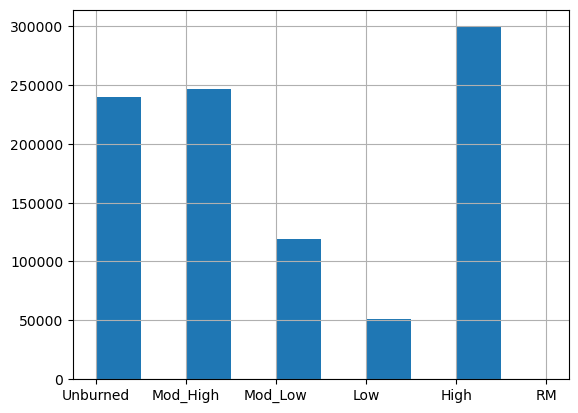

In [8]:
graf=dfMag['Severity'].hist()
figura = graf.get_figure()
figura.savefig('Severidad_Catalunia_MFE85.png')

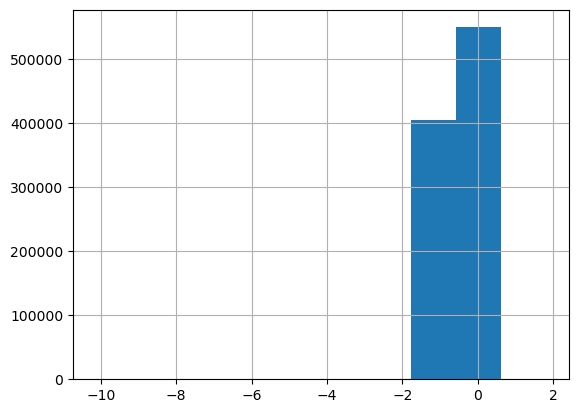

In [9]:
graf=dfMag['Magnitude'].hist()
figura = graf.get_figure()
figura.savefig('Magnitud_Catalunia_MFE85.png')

In [10]:
#Estadísticas de pendiente.

slope_dir = "D:\giambelluca.144055\Incendios\Proyecto\Rasters_stat\Slope_Catalunia_4326.tif"
Slope=gdal.Open(slope_dir)
Slope=Slope.GetRasterBand(1).ReadAsArray()



In [12]:
dfslope = []

# Bucle que permite leer cada uno de los rasters de incendios
 
Bosques=bosques.GetRasterBand(1).ReadAsArray()

#Buscar la fecha en el dataframe y extraer los incendios que le corresponden

lista=list(set(df['ID_total']))
    #Con el nombre de los incendios enmascarar los bosques prendidos fuego
for y in range(len(lista)):
    none_mask = (Bosques == lista[y])
    none_indices = np.argwhere(none_mask)
        #Extraer la magnitud de los incendios para cada bosque
    informacion_extraida = list(Slope[none_indices[:, 0], none_indices[:, 1]])
    name=str(lista[y])        
        #crear un df temporal y almacenar la información en la lista dfs
    fire = [name] * len(informacion_extraida)
                # Crea un DataFrame temporal con la información extraída
    filas=list(none_indices)
    df_temporal = pd.DataFrame({'ID_forest': fire, 'Slope': informacion_extraida,'Row':filas})
        
        # Agrega el DataFrame temporal al DataFrame principal
    dfslope.append(df_temporal)

# Concatenar toda la información en un único dataframe.
dfSlope = pd.concat(dfslope, ignore_index=True)

C:\Users\giambelluca.144055\AppData\Local\Temp\ipykernel_28312\4166472485.py:27: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfSlope = pd.concat(dfslope, ignore_index=True)


In [ ]:
len(dfSlope)

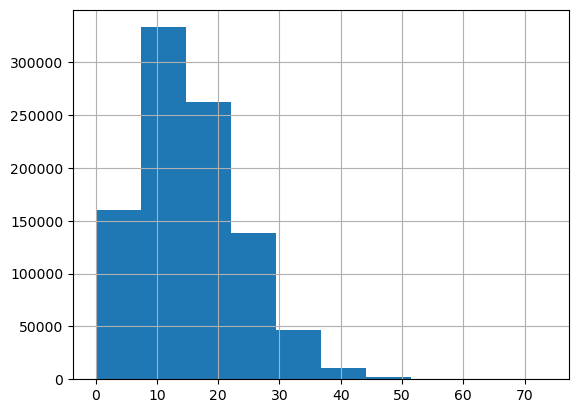

In [13]:
graf=dfSlope['Slope'].hist()
figura = graf.get_figure()
figura.savefig('Pendiente_Catalunia_MFE85.png')

In [14]:
#Estadisticas aspect

aspect_dir = "D:\giambelluca.144055\Incendios\Proyecto\Rasters_stat\Aspect_Catalunia_4326.tif"
Aspect=gdal.Open(aspect_dir)
Aspect=Aspect.GetRasterBand(1).ReadAsArray()

dfaspect = []

# Bucle que permite leer cada uno de los rasters de incendios
 
Bosques=bosques.GetRasterBand(1).ReadAsArray()

#Buscar la fecha en el dataframe y extraer los incendios que le corresponden

lista=list(set(df['ID_total']))
    #Con el nombre de los incendios enmascarar los bosques prendidos fuego
for y in range(len(lista)):
    none_mask = (Bosques == lista[y])
    none_indices = np.argwhere(none_mask)
        #Extraer la magnitud de los incendios para cada bosque
    informacion_extraida = list(Aspect[none_indices[:, 0], none_indices[:, 1]])
    name=str(lista[y])        
        #crear un df temporal y almacenar la información en la lista dfs
    fire = [name] * len(informacion_extraida)
                # Crea un DataFrame temporal con la información extraída
    filas=list(none_indices)
    df_temporal = pd.DataFrame({'ID_forest': fire, 'Aspect': informacion_extraida,'Row':filas})
        
        # Agrega el DataFrame temporal al DataFrame principal
    dfaspect.append(df_temporal)

# Concatenar toda la información en un único dataframe.
dfAspect = pd.concat(dfaspect, ignore_index=True)
# dfAspect['ID_forest']=dfAspect['ID_forest'].astype(str)
# dfAspect['ID_Fire'], dfAspect['ID_Sp'] = dfAspect['ID_forest'].str.split('9990', 1).str


C:\Users\giambelluca.144055\AppData\Local\Temp\ipykernel_28312\2375157547.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfAspect = pd.concat(dfaspect, ignore_index=True)


In [15]:
dfAspect.loc[(dfAspect['Aspect'] >=315), ['Face']] = ['N']
dfAspect.loc[(dfAspect['Aspect'] <45), ['Face']] = ['N']
dfAspect.loc[(dfAspect['Aspect'] >=45)&(dfAspect['Aspect']<135), ['Face']] = ['E']
dfAspect.loc[(dfAspect['Aspect'] >=135)&(dfAspect['Aspect']<225), ['Face']] = ['S']
dfAspect.loc[(dfAspect['Aspect'] >=225)&(dfAspect['Aspect']<315), ['Face']] = ['W']

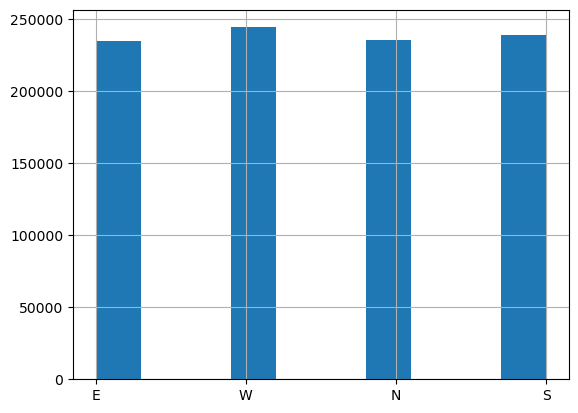

In [16]:
graf=dfAspect['Face'].hist()
figura = graf.get_figure()
figura.savefig('Orientacion_Catalunia_MFE85.png')

In [17]:
#Estadisticas TRSI

trsi_dir = "D:\giambelluca.144055\Incendios\Proyecto\Rasters_stat\TRSI_Catalunia_4326.tif"
TRSI=gdal.Open(trsi_dir)
TRSI=TRSI.GetRasterBand(1).ReadAsArray()

dftrsi = []

# Bucle que permite leer cada uno de los rasters de incendios
 
Bosques=bosques.GetRasterBand(1).ReadAsArray()

#Buscar la fecha en el dataframe y extraer los incendios que le corresponden

lista=list(set(df['ID_total']))
    #Con el nombre de los incendios enmascarar los bosques prendidos fuego
for y in range(len(lista)):
    none_mask = (Bosques == lista[y])
    none_indices = np.argwhere(none_mask)
        #Extraer la magnitud de los incendios para cada bosque
    informacion_extraida = list(TRSI[none_indices[:, 0], none_indices[:, 1]])
    name=str(lista[y])        
        #crear un df temporal y almacenar la información en la lista dfs
    fire = [name] * len(informacion_extraida)
                # Crea un DataFrame temporal con la información extraída
    filas=list(none_indices)
    df_temporal = pd.DataFrame({'ID_forest': fire, 'TRSI': informacion_extraida,'Row':filas})
        
        # Agrega el DataFrame temporal al DataFrame principal
    dftrsi.append(df_temporal)

# Concatenar toda la información en un único dataframe.
dfTRSI = pd.concat(dftrsi, ignore_index=True)
# dfTRSI['ID_forest']=dfTRSI['ID_forest'].astype(str)
# dfTRSI['ID_Fire'], dfTRSI['ID_Sp'] = dfTRSI['ID_forest'].str.split('9990', 1).str


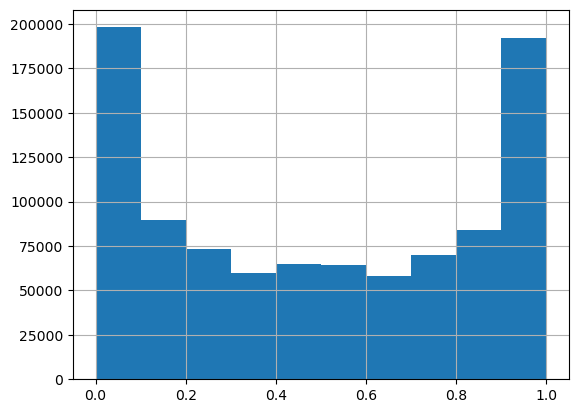

In [18]:
graf=dfTRSI['TRSI'].hist()
figura = graf.get_figure()
figura.savefig('TRSI_Catalunia_MFE85.png')

In [19]:
#Estadisticas Elevacion

high_dir = "D:\giambelluca.144055\Incendios\Proyecto\Rasters_stat\High_Catalunia_4326.tif"
High=gdal.Open(high_dir)
High=High.GetRasterBand(1).ReadAsArray()

dfhigh = []

# Bucle que permite leer cada uno de los rasters de incendios
 
Bosques=bosques.GetRasterBand(1).ReadAsArray()

#Buscar la fecha en el dataframe y extraer los incendios que le corresponden

lista=list(set(df['ID_total']))
    #Con el nombre de los incendios enmascarar los bosques prendidos fuego
for y in range(len(lista)):
    none_mask = (Bosques == lista[y])
    none_indices = np.argwhere(none_mask)
        #Extraer la magnitud de los incendios para cada bosque
    informacion_extraida = list(High[none_indices[:, 0], none_indices[:, 1]])
    name=str(lista[y])        
        #crear un df temporal y almacenar la información en la lista dfs
    fire = [name] * len(informacion_extraida)
                # Crea un DataFrame temporal con la información extraída
   
    filas=list(none_indices)
    df_temporal = pd.DataFrame({'ID_forest': fire, 'Height': informacion_extraida,'Row':filas})
        # Agrega el DataFrame temporal al DataFrame principal
    dfhigh.append(df_temporal)

# Concatenar toda la información en un único dataframe.
dfHigh = pd.concat(dfhigh, ignore_index=True)


C:\Users\giambelluca.144055\AppData\Local\Temp\ipykernel_28312\3842702078.py:33: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  dfHigh = pd.concat(dfhigh, ignore_index=True)


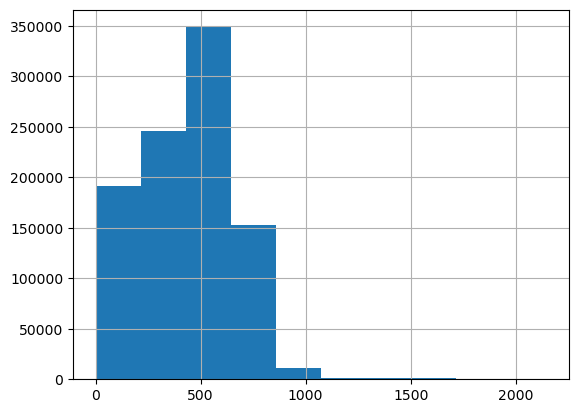

In [20]:
graf=dfHigh['Height'].hist()
figura = graf.get_figure()
figura.savefig('Elevacion_Catalunia_MFE85.png')

In [21]:
#Estadisticas North

North_dir = "D:\\giambelluca.144055\\Incendios\\Proyecto\\Rasters_stat\\Catalunia_North_4326.tif"
North=gdal.Open(North_dir)
North=North.GetRasterBand(1).ReadAsArray()

dfnorth = []

# Bucle que permite leer cada uno de los rasters de incendios
 
Bosques=bosques.GetRasterBand(1).ReadAsArray()

#Buscar la fecha en el dataframe y extraer los incendios que le corresponden

lista=list(set(df['ID_total']))
    #Con el nombre de los incendios enmascarar los bosques prendidos fuego
for y in range(len(lista)):
    none_mask = (Bosques == lista[y])
    none_indices = np.argwhere(none_mask)
        #Extraer la magnitud de los incendios para cada bosque
    informacion_extraida = list(North[none_indices[:, 0], none_indices[:, 1]])
    name=str(lista[y])        
        #crear un df temporal y almacenar la información en la lista dfs
    fire = [name] * len(informacion_extraida)
                # Crea un DataFrame temporal con la información extraída
    filas=list(none_indices)
    df_temporal = pd.DataFrame({'ID_forest': fire, 'North': informacion_extraida,'Row':filas})
        
        # Agrega el DataFrame temporal al DataFrame principal
    dfnorth.append(df_temporal)

# Concatenar toda la información en un único dataframe.
dfNorth = pd.concat(dfnorth, ignore_index=True)

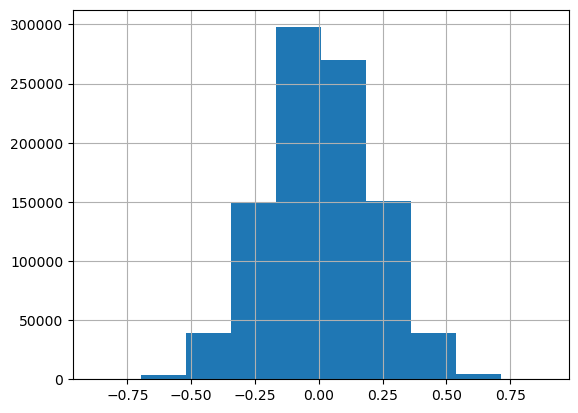

In [22]:
graf=dfNorth['North'].hist()
figura = graf.get_figure()
figura.savefig('North_Catalunia_MFE85.png')

In [24]:
#Estadisticas East

East_dir = "D:\\giambelluca.144055\\Incendios\\Proyecto\\Rasters_stat\\E_Catalunia.tif"
East=gdal.Open(East_dir)
East=East.GetRasterBand(1).ReadAsArray()

dfeast = []

# Bucle que permite leer cada uno de los rasters de incendios
 
Bosques=bosques.GetRasterBand(1).ReadAsArray()

#Buscar la fecha en el dataframe y extraer los incendios que le corresponden

lista=list(set(df['ID_total']))
    #Con el nombre de los incendios enmascarar los bosques prendidos fuego
for y in range(len(lista)):
    none_mask = (Bosques == lista[y])
    none_indices = np.argwhere(none_mask)
        #Extraer la magnitud de los incendios para cada bosque
    informacion_extraida = list(East[none_indices[:, 0], none_indices[:, 1]])
    name=str(lista[y])        
        #crear un df temporal y almacenar la información en la lista dfs
    fire = [name] * len(informacion_extraida)
                # Crea un DataFrame temporal con la información extraída
    filas=list(none_indices)
    df_temporal = pd.DataFrame({'ID_forest': fire, 'East': informacion_extraida,'Row':filas})
        
        # Agrega el DataFrame temporal al DataFrame principal
    dfeast.append(df_temporal)

# Concatenar toda la información en un único dataframe.
dfEast = pd.concat(dfeast, ignore_index=True)

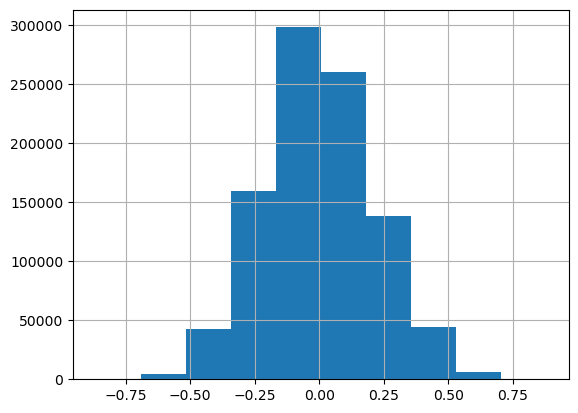

In [25]:
graf=dfEast['East'].hist()
figura = graf.get_figure()
figura.savefig('East_Catalunia_MFE85.png')

In [ ]:
gdal.SetConfigOption("GDAL_CACHEMAX", "2000")

In [26]:
dfMag['Row']=dfMag['Row'].astype(str)
dfSlope['Row']=dfSlope['Row'].astype(str)
dfAspect['Row']=dfAspect['Row'].astype(str)
dfHigh['Row']=dfHigh['Row'].astype(str)
dfTRSI['Row']=dfTRSI['Row'].astype(str)
dfNorth['Row']=dfNorth['Row'].astype(str)
dfEast['Row']=dfEast['Row'].astype(str)
dfSlope=dfSlope.drop(columns=['ID_forest'])
dfAspect=dfAspect.drop(columns=['ID_forest'])
dfHigh=dfHigh.drop(columns=['ID_forest'])
dfTRSI=dfTRSI.drop(columns=['ID_forest'])
dfNorth=dfNorth.drop(columns=['ID_forest'])
dfEast=dfEast.drop(columns=['ID_forest'])

In [27]:
union=pd.merge(dfMag, dfSlope, on='Row', how='inner')
union=pd.merge(union, dfAspect, on='Row', how='inner')
union=pd.merge(union, dfTRSI, on='Row', how='inner')
union=pd.merge(union, dfHigh, on='Row', how='inner')
union=pd.merge(union, dfNorth, on='Row', how='inner')
union=pd.merge(union, dfEast, on='Row', how='inner')
union

,ID_forest,Magnitude,Row,Severity,Slope,Aspect,Face,TRSI,Height,North,East
0,22534.0,0.000000,[5067 6357],Unburned,15.603019,58.553875,E,0.961697,502.0,0.140321,0.229467
1,22534.0,0.000000,[5068 6357],Unburned,8.669277,96.094482,E,0.983035,505.0,-0.016003,0.149879
2,22534.0,-0.596560,[5074 6373],Mod_High,26.408007,299.273499,W,0.106786,499.0,0.217479,-0.387962
3,22534.0,-0.567480,[5074 6374],Mod_High,10.206794,302.645538,W,0.125632,507.0,0.095590,-0.149208
4,22534.0,0.000000,[5074 6375],Unburned,8.812158,102.054390,E,0.967016,506.0,-0.031994,0.149818
...,...,...,...,...,...,...,...,...,...,...,...
955742,431324.0,-0.258644,[4921 6939],Low,12.292206,243.528397,W,0.023400,240.0,-0.094900,-0.190577
955743,431324.0,0.000000,[4921 6940],Unburned,11.280262,229.514236,W,0.074193,244.0,-0.127000,-0.148774
955744,431324.0,-0.348960,[4922 6946],Mod_Low,20.011593,212.381226,S,0.170296,258.0,-0.288998,-0.183271
955745,431324.0,-0.253272,[4922 6947],Low,21.902035,202.168701,S,0.242166,262.0,-0.345446,-0.140754


In [28]:
nueva_ruta = 'D:\\giambelluca.144055\\Incendios\\Proyecto\\Statis_CCAA\\Stat_Catalunia_MFE85.csv'
union.to_csv(nueva_ruta, index=False)